In [2]:
using TransVis
trajectories, active_trajectory_name = get_data_alt()
active_trajectory = trajectories[active_trajectory_name]

Precompiling TransVis
  ✓ TransVis
  1 dependency successfully precompiled in 7 seconds. 302 already precompiled.


Loading nano_pt from cache.
  9.187205 seconds (17.01 M allocations: 2.399 GiB, 14.32% gc time, 38.85% compilation time: 12% of which was recompilation)


Dict{String, Any} with 11 entries:
  "t3"                       => Dict((594, 595)=>[0.283187, -0.560453, -0.33271…
  "alignedPositionsMatrices" => Dict{Tuple{Int64, Int64}, Tuple{Matrix, Matrix}…
  "alignedPositions"         => Dict{Tuple{Int64, Int64}, Tuple{Vector{Point{3,…
  "connectivity"             => Dict{Int64, Matrix}(1144=>Int8[1 0 … 0 0; 0 1 ……
  "transitions"              => Set([(594, 595), (647, 659), (1471, 1472), (230…
  "t2"                       => Dict((594, 595)=>[0.00476196, 0.00323499, 0.003…
  "t1"                       => Dict((594, 595)=>[0.000634336, -0.003602, -0.00…
  "stretchedPrincipalAxes"   => Dict{Tuple{Int64, Int64}, Vector{Vector{Vec{3, …
  "distanceMatrices"         => Dict{Int64, Matrix}(1144=>[0.0 5.35064 … 7.0324…
  "dms"                      => Dict{Any, Any}("atom_invariants"=>Dict{String, …
  "kdTree"                   => Dict{Tuple{Int64, Int64}, Tuple{KDTree, KDTree}…

In [11]:
function get_from_t_dict(d, t::Tuple{Int,Int})
    val = get(d, t, Nothing)
    if val === Nothing
        s1, s2 = t
        return get(d, (s2, s1), Nothing)
    end
    return val
end

get_from_t_dict (generic function with 1 method)

In [12]:
transitionInvariants1 = active_trajectory["t1"]
alignedPositions = active_trajectory["alignedPositions"]
alignedPositionsMat = active_trajectory["alignedPositionsMatrices"]
transitionKDTree = active_trajectory["kdTree"]

Dict{Tuple{Int64, Int64}, Tuple{NearestNeighbors.KDTree, NearestNeighbors.KDTree}} with 2841 entries:
  (594, 595)   => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (647, 659)   => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (1471, 1472) => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (2305, 2306) => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (2037, 2036) => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (921, 922)   => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (2182, 2183) => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (178, 179)   => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (1378, 1379) => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (1333, 1334) => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (1065, 1066) => (KDTree{Point{3, Float32}, Euclidean, Float32, SVector{3, Flo…
  (1014

In [6]:
t1 = (594, 595)
t2 = (647, 659)

(647, 659)

In [8]:
minInvariant1 = 1.0e10
maxInvariant2 = -1.0e10
@time for (key, value) in transitionInvariants1
    for invariant1 in value
        if minInvariant1 > invariant1
            minInvariant1 = invariant1
        end
        if maxInvariant2 < invariant1
            maxInvariant2 = invariant1
        end
    end
end
println("invariant range:  $(minInvariant1) -  $(maxInvariant2)")

  0.124939 seconds (1.14 M allocations: 26.269 MiB, 50.67% compilation time)
invariant range:  -0.30663428469893345 -  0.39713675542850563


In [10]:
numberOfBins = 100
stepSize = (maxInvariant2 - minInvariant1) / numberOfBins
binEdges = [minInvariant1:stepSize:maxInvariant2;]

101-element Vector{Float64}:
 -0.30663428469893345
 -0.29959657429765907
 -0.2925588638963847
 -0.28552115349511026
 -0.2784834430938359
 -0.2714457326925615
 -0.2644080222912871
 -0.2573703118900127
 -0.2503326014887383
 -0.24329489108746394
 -0.23625718068618956
 -0.22921947028491516
 -0.22218175988364075
  ⋮
  0.3197219410144873
  0.32675965141576174
  0.33379736181703606
  0.3408350722183105
  0.3478727826195848
  0.35491049302085925
  0.3619482034221337
  0.368985913823408
  0.37602362422468244
  0.38306133462595676
  0.3900990450272312
  0.39713675542850563

In [18]:
using GeometryBasics
using NearestNeighbors
using StatsBase, SparseArrays, Distances

function computeInvariantDistributionInNeighborhood(data::Vector{Float64}, positions::Vector{Point3f}, binEdges::Vector{Float64}, neighborCount::Int64, atomKDTree::NearestNeighbors.KDTree)::Vector{SparseVector{Float64}}
    distributionsAtPositions = Vector{SparseVector{Float64}}()
    for position in positions
        nns, dists = knn(atomKDTree, position, neighborCount)
        #add minimum distance
        vals = data[nns]
        histo = fit(Histogram, vals, binEdges; closed=:right)
        pd = StatsBase.normalize(histo; mode=:probability)
        push!(distributionsAtPositions, sparse(pd.weights))
    end
    return distributionsAtPositions
end

computeInvariantDistributionInNeighborhood (generic function with 1 method)

In [27]:
function computeLNCD(a, b)::Float64 #local neighborhood cummulative diverge score
    informationScore = 0.0
    for i in 1:size(a)[1]
        informationScore = informationScore + JSDivergence()(a[i], b[i])
    end
    return informationScore
end

computeLNCD (generic function with 1 method)

In [32]:
import Pkg
Pkg.add("Rotations")

   Resolving package versions...
   Installed RealDot ───── v0.1.0
   Installed Quaternions ─ v0.7.6
   Installed Rotations ─── v1.7.1
    Updating `~/Programs/Julia/TransVis/Project.toml`
  [6038ab10] + Rotations v1.7.1
    Updating `~/Programs/Julia/TransVis/Manifest.toml`
  [94ee1d12] + Quaternions v0.7.6
  [c1ae055f] + RealDot v0.1.0
  [6038ab10] + Rotations v1.7.1
Precompiling project...
  ✓ RealDot
  ✓ Quaternions
  ✓ Rotations
  ✓ Rotations → RotationsRecipesBaseExt
  ✓ TransVis
  5 dependencies successfully precompiled in 10 seconds. 302 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version


In [43]:
Pkg.add("Plots")

   Resolving package versions...
   Installed LERC_jll ───────────────────── v4.0.0+0
   Installed Measures ───────────────────── v0.3.2
   Installed LoggingExtras ──────────────── v1.1.0
   Installed Xorg_xkbcomp_jll ───────────── v1.4.6+0
   Installed GR_jll ─────────────────────── v0.73.8+0
   Installed ConcurrentUtilities ────────── v2.4.2
   Installed Unitful ────────────────────── v1.21.0
   Installed Xorg_xcb_util_image_jll ────── v0.4.0+1
   Installed RecipesPipeline ────────────── v0.6.12
   Installed Xorg_xcb_util_wm_jll ───────── v0.4.1+1
   Installed OpenSSL ────────────────────── v1.4.3
   Installed HTTP ───────────────────────── v1.10.9
   Installed Xorg_libSM_jll ─────────────── v1.2.4+0
   Installed Xorg_xcb_util_jll ──────────── v0.4.0+1
   Installed EpollShim_jll ──────────────── v0.0.20230411+0
   Installed Xorg_libxkbfile_jll ────────── v1.1.2+0
   Installed FFMPEG ─────────────────────── v0.2.4
   Installed DelimitedFiles ─────────────── v1.9.1
   Installed xkbcomm

In [59]:
Pkg.add("CoordinateTransformations")

   Resolving package versions...
   Installed CoordinateTransformations ─ v0.6.3
    Updating `~/Programs/Julia/TransVis/Project.toml`
  [150eb455] + CoordinateTransformations v0.6.3
    Updating `~/Programs/Julia/TransVis/Manifest.toml`
  [150eb455] + CoordinateTransformations v0.6.3
Precompiling project...
  ✓ CoordinateTransformations
  1 dependency successfully precompiled in 1 seconds. 367 already precompiled.


In [60]:
using CoordinateTransformations, Rotations

In [144]:
refiv1 = transitionInvariants1[t2]
p1ref, p2ref = get_from_t_dict(alignedPositionsMat, t2)
refk1, refk2 = get_from_t_dict(transitionKDTree, t2)
refPoints = map(p -> Point3f(p), eachrow(p1ref))
refDist = computeInvariantDistributionInNeighborhood(refiv1, refPoints, binEdges, 10, KDTree(refPoints))

147-element Vector{SparseVector{Float64}}:
   [43]  =  0.5
  [44]  =  0.5
   [43]  =  0.3
  [44]  =  0.6
  [45]  =  0.1
   [43]  =  0.2
  [44]  =  0.8
   [41]  =  0.1
  [43]  =  0.4
  [44]  =  0.4
  [45]  =  0.1
   [38]  =  0.1
  [39]  =  0.1
  [40]  =  0.1
  [42]  =  0.1
  [45]  =  0.2
  [46]  =  0.2
  [47]  =  0.1
  [54]  =  0.1
   [44]  =  0.9
  [46]  =  0.1
   [42]  =  0.1
  [44]  =  0.5
  [45]  =  0.1
  [46]  =  0.3
   [38]  =  0.1
  [40]  =  0.1
  [42]  =  0.2
  [43]  =  0.1
  [44]  =  0.1
  [45]  =  0.2
  [46]  =  0.1
  [47]  =  0.1
   [42]  =  0.2
  [43]  =  0.3
  [44]  =  0.5
   [42]  =  0.1
  [43]  =  0.4
  [44]  =  0.5
   [40]  =  0.2
  [42]  =  0.1
  [43]  =  0.1
  [44]  =  0.2
  [45]  =  0.1
  [46]  =  0.3
   [43]  =  0.2
  [44]  =  0.1
  [45]  =  0.1
  [46]  =  0.3
  [47]  =  0.2
  [54]  =  0.1
   [37]  =  0.1
  [38]  =  0.2
  [39]  =  0.1
  [40]  =  0.1
  [42]  =  0.1
  [44]  =  0.1
  [46]  =  0.1
  [48]  =  0.1
  [54]  =  0.1
 ⋮
   [38]  =  0.1
  [42]  =  0.1
  [43]  = 

In [165]:
minV = typemax(Float64)
minRot = nothing
p1t1mat, p2t1mat = get_from_t_dict(alignedPositionsMat, t1)        
tMat = vcat(p1t1mat, p2t1mat+trans)
t1iv1 = transitionInvariants1[t1]

for x in 0:pi/6:2*pi
    for y in 0:pi/6:2*pi
        rotMat = RotX(x) * RotY(y)
        rot = ((p1t1mat+center) * rotMat) - center #p1t1mat * rotMat
        points = map(p -> Point3f(p), eachrow(rot))
        dist = computeInvariantDistributionInNeighborhood(refiv1, points, binEdges, 10, KDTree(refPoints))
        i = computeLNCD(dist, refDist)
        if i < minV
            minV = i
            minRot = rotMat
        end
    end
end
println(minV,minRot)

21.430246854729596[0.49999999999999933 0.0 -0.866025403784439; -0.0 1.0 -0.0; 0.866025403784439 0.0 0.49999999999999933]


In [161]:
using Plots
#using CoordinateTransformations, Rotations
trans = zeros(147, 3)
trans[:, 1, :] .= 30
trans

147×3 Matrix{Float64}:
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
  ⋮         
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0
 30.0  0.0  0.0

In [160]:
center = zeros(147, 3)
center[:, :, :] .= -15

147×3×1 view(::Array{Float64, 3}, :, :, :) with eltype Float64:
[:, :, 1] =
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
   ⋮           
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0
 -15.0  -15.0  -15.0

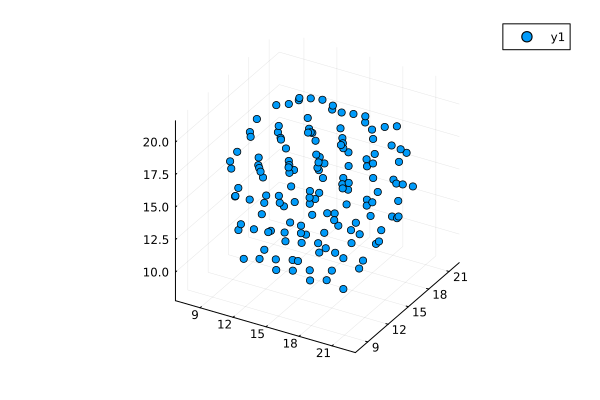

In [168]:
plt3d = Plots.plot(map(x -> Point3f(x), eachrow(p1ref)), seriestype=:scatter)
display(plt3d)

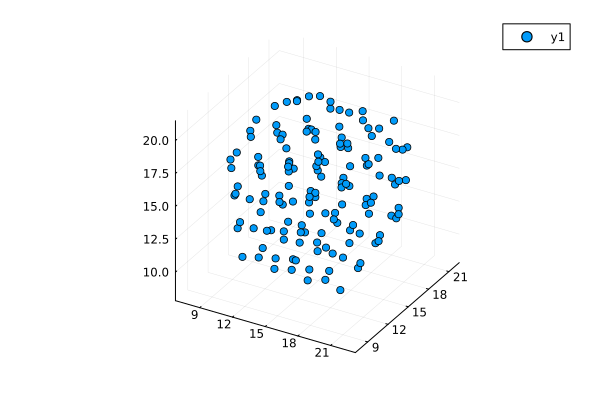

In [171]:
plt3d = Plots.plot(map(x -> Point3f(x), eachrow(p2ref)), seriestype=:scatter)
display(plt3d)

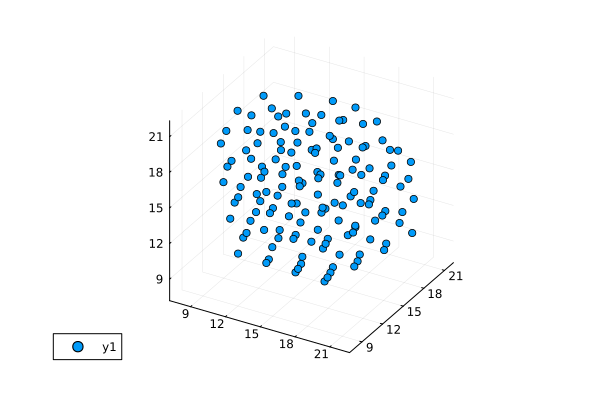

In [167]:
tMat = vcat(p1t1mat, p2t1mat+trans)
plt3d = Plots.plot(map(x -> Point3f(x), eachrow(p1t1mat)), seriestype=:scatter)
display(plt3d)

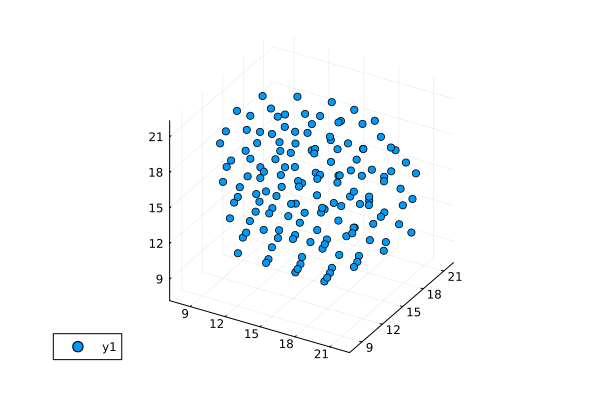

In [169]:
plt3d = Plots.plot(map(x -> Point3f(x), eachrow(p2t1mat)), seriestype=:scatter)
display(plt3d)

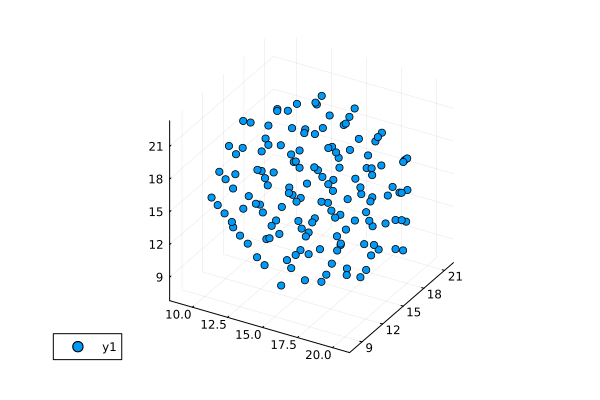

In [166]:
rot = ((p1t1mat+center) * minRot) - center
plt3d = Plots.plot(map(x -> Point3f(x), eachrow(rot)), seriestype=:scatter)
display(plt3d)

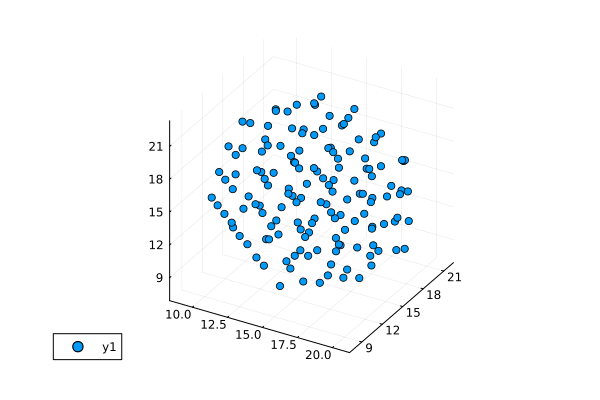

In [170]:
rot = ((p2t1mat+center) * minRot) - center
plt3d = Plots.plot(map(x -> Point3f(x), eachrow(rot)), seriestype=:scatter)
display(plt3d)